In [18]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGSMITH_TRACING"]="true"
os.environ["LANGSMITH_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")
groq_model_name=os.getenv("GROQ_MODEL_NAME")

LANGGRAPH_DEBUGGING


In [20]:
from langchain.chat_models import init_chat_model
llm = init_chat_model(f"groq:{groq_model_name}")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001EAF74A60F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001EAF74C2ED0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [21]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [ ]:
## Graph With tool Call
from langchain_core.tools import tool

@tool
def add(a:float,b:float):
    """Add two number"""
    return a+b
tools=[add]
tool_node=ToolNode(tools)

llm_with_tool=llm.bind_tools(tools)

In [23]:
# Node definition
def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}


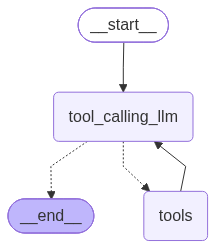

In [ ]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools",tool_node)

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response=graph.invoke({"messages":"What is machine learning"})
response

{'messages': [HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}, id='ccf5f8ff-2b39-4843-8d8f-2fe19341c2e2'),
  AIMessage(content='Machine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform a specific task without using explicit instructions. Instead, the machine learns from data, making predictions or decisions based on that data. The goal of machine learning is to develop algorithms that can learn from data and improve their performance on a task over time, without being explicitly programmed for that task.\n\nThere are several types of machine learning, including:\n\n1. Supervised learning: The machine is trained on labeled data, where the correct output is already known.\n2. Unsupervised learning: The machine is trained on unlabeled data, and it must find patterns or structure in the data.\n3. Reinforcement learning: The machine learns by interacting w

In [26]:
response=graph.invoke({"messages":"What is 2 plus 3"})
response

{'messages': [HumanMessage(content='What is 2 plus 3', additional_kwargs={}, response_metadata={}, id='e637a960-d51a-4b9c-b94f-86fdef1a6e85'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pcwkj7a48', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 219, 'total_tokens': 237, 'completion_time': 0.039426722, 'completion_tokens_details': None, 'prompt_time': 0.011444927, 'prompt_tokens_details': None, 'queue_time': 0.058512752, 'total_time': 0.050871649}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fc855-da96-7ed3-9761-e1a3c1b487ba-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 3}, 'id': 'pcwkj7a48', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 219, 'output_tokens': 18

### We can check the Langsmith dashboard for the execution flow, debugging and monitoring purpose